In [186]:
import random
import os
val_paths = []
root = '/path/to/casia-webface'
with open("../../data_splits/index.txt","r") as f:
    lines = f.readlines()
    for line in lines:
        filename, split = line.strip().split()
        if split != "train":
            val_paths.append(os.path.join(root, filename)) 
        
val_paths = random.sample(val_paths, k=50)

In [187]:
from PIL import Image
import numpy as np
import torch
images = []
for path in sorted(val_paths):
    img = Image.open(path).convert("RGB")
    img = img.resize((112,112))
    img = np.array(img).astype(np.float32)
    img = torch.from_numpy(img).permute(2,0,1) / 255.0
    images.append(img.mean(dim=0, keepdim=True))

In [188]:
import sys
sys.path.append("../../methods/fracface")
import data2npy

In [189]:
templates = [] 
for img in sorted(val_paths):
    img = Image.open(img).convert("RGB")
    t = data2npy.preprocess_and_return(img, 1)[0].mean(dim=0, keepdim=True)
    templates.append(t)

In [201]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, padding_mode='replicate'),
    torch.nn.ReLU(),
    torch.nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1, padding_mode='replicate'),
)

In [202]:
# tensor datasets
import torch.utils.data as data_utils
tensor_x = torch.stack(images)
tensor_y = torch.stack(templates)
dataset_train = data_utils.TensorDataset(tensor_x[2:], tensor_y[2:])
dataset_val = data_utils.TensorDataset(tensor_x[:2], tensor_y[:2])
loader = data_utils.DataLoader(dataset_train, batch_size=2, shuffle=True)
val_loader = data_utils.DataLoader(dataset_val, batch_size=2, shuffle=False)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
for epoch in range(10):
    for batch_idx, (data, target) in enumerate(loader):
        optimizer.zero_grad()
        output = model(data)
        scale = (target.max() - target.min() + 1e-8)
        loss = torch.nn.functional.mse_loss(output, target) * scale
        loss.backward()
        optimizer.step() 
    print(f"Epoch {epoch} Batch {batch_idx} Loss {loss.item():.6f}")
    for val_data, val_target in val_loader:
        val_output = model(val_data)
        val_loss = torch.nn.functional.mse_loss(val_output, val_target)
        scale = (val_target.max() - val_target.min() + 1e-8)
        print(f"Validation Loss: {val_loss.item():.6f}")

Epoch 0 Batch 23 Loss 0.000125
Validation Loss: 0.018804
Epoch 1 Batch 23 Loss 0.051844
Validation Loss: 0.018395
Epoch 2 Batch 23 Loss 0.001041
Validation Loss: 0.018009
Epoch 3 Batch 23 Loss 0.000480
Validation Loss: 0.017722
Epoch 4 Batch 23 Loss 0.000459
Validation Loss: 0.017466
Epoch 5 Batch 23 Loss 0.002066
Validation Loss: 0.017281
Epoch 6 Batch 23 Loss 0.000053
Validation Loss: 0.017140
Epoch 7 Batch 23 Loss 0.022149
Validation Loss: 0.017029
Epoch 8 Batch 23 Loss 0.045048
Validation Loss: 0.016940
Epoch 9 Batch 23 Loss 0.001495
Validation Loss: 0.016855


In [204]:
val_target.max(), target.max() 

(tensor(2.6204), tensor(0.6584))

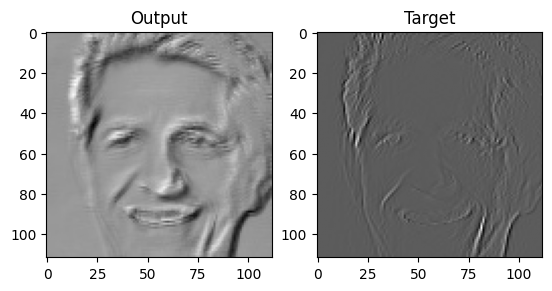

In [ ]:
import pylab
val_o = val_output[1].detach().cpu().numpy()[0]
val_t = val_target[1].detach().cpu().numpy()[0]
pylab.subplot(1,2,1)
pylab.imshow(val_o, cmap='gray')
pylab.title("Output")
pylab.subplot(1,2,2)
pylab.imshow(val_t, cmap='gray')
pylab.title("Target") 
pylab.show() 